In [9]:
import numpy as np
def prob(w, X):
    """
    X: a 2d numpy array of shape (N, d). N datatpoint, each with size d
    w: a 1d numpy array of shape (d)
    """
    return sigmoid(X.dot(w))
def loss(w, X, y, lam):
    """
    X, w as in prob
    y: a 1d numpy array of shape (N). Each elem = 0 or 1
    """
    z = prob(w, X)
    return -np.mean(y*np.log(z) + (1-y)*np.log(1-z)) + 0.5*lam/X.shape[0]*np.sum(w*w)
def sigmoid(x):
    """
    Calculate the sigmoid function.
    
    The sigmoid function maps any input to a value between 0 and 1.
    Formula: sigmoid(x) = 1 / (1 + e^(-x))
    
    Args:
        x: Input value (int, float, or numpy array)
    
    Returns:
        Sigmoid of x, bounded between 0 and 1
    """
    #import math
    
    return np.where(
            x >= 0,
            1 / (1 + np.exp(-x)),
            np.exp(x) / (1 + np.exp(x))
        )


In [19]:
def logistic_regression(w_init, X, y, lam = 0.001, lr = 0.1, nepoches = 20000):
# lam - reg paramether, lr - learning rate, nepoches - number of epoches
    N, d = X.shape[0], X.shape[1]
    w = w_old = w_init
    loss_hist = [loss(w_init, X, y, lam)] # store history of loss in loss_hist
    ep = 0
    while ep < nepoches:
        ep += 1
        mix_ids = np.random.permutation(N)
        for i in mix_ids:
            xi = X[i]
            yi = y[i]
            zi = sigmoid(xi.dot(w))
            w = w - lr*((zi - yi)*xi + lam*w)
        loss_hist.append(loss(w, X, y, lam))
        if np.linalg.norm(w - w_old)/d < 1e-6:
            break
        w_old = w
    return w, loss_hist

In [22]:
X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50,
2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]]).T
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])
X.shape
# bias trick
Xbar = np.concatenate((X, np.ones((20, 1))), axis = 1)
w_init = np.random.randn(Xbar.shape[1])
lam = 0.0001
w, loss_hist = logistic_regression(w_init, Xbar, y, lam, lr = 0.05, nepoches = 100000)
print(w)
print(loss(w, Xbar, y, lam))

[ 1.41629101 -4.10112295]
0.40636050871288437


**BÀI TOÁN PHÂN BIỆT CHỮ SỐ VIẾT TAY**

In [25]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load MNIST dataset using fetch_openml (modern replacement for fetch_mldata)
mnist = fetch_openml('mnist_784', version=1, as_frame=False, data_home='../../data/')

X, y = mnist.data, mnist.target
N, d = X.shape


In [41]:
X_all = mnist.data
y_all = mnist.target
X_all[0].shape
y_all.distinct()

AttributeError: 'numpy.ndarray' object has no attribute 'distinct'

In [42]:
X0 = X_all[np.where(y_all == '0')[0]] # all digit 0
X1 = X_all[np.where(y_all == '1')[0]] # all digit 1
y0 = np.zeros(X0.shape[0]) # class 0 label
y1 = np.ones(X1.shape[0]) # class 1 label
X = np.concatenate((X0, X1), axis = 0) # all digits
y = np.concatenate((y0, y1)) # all labels
X0.shape, y1.shape

((6903, 784), (7877,))

In [48]:
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=3000)
    model = LogisticRegression(C = 1e5) # C is inverse of lam
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(100*accuracy_score(y_test, y_pred.tolist()))

99.86666666666667
99.93333333333332
99.76666666666667
99.93333333333332
99.9
99.9
99.9
99.9
99.9
99.96666666666667


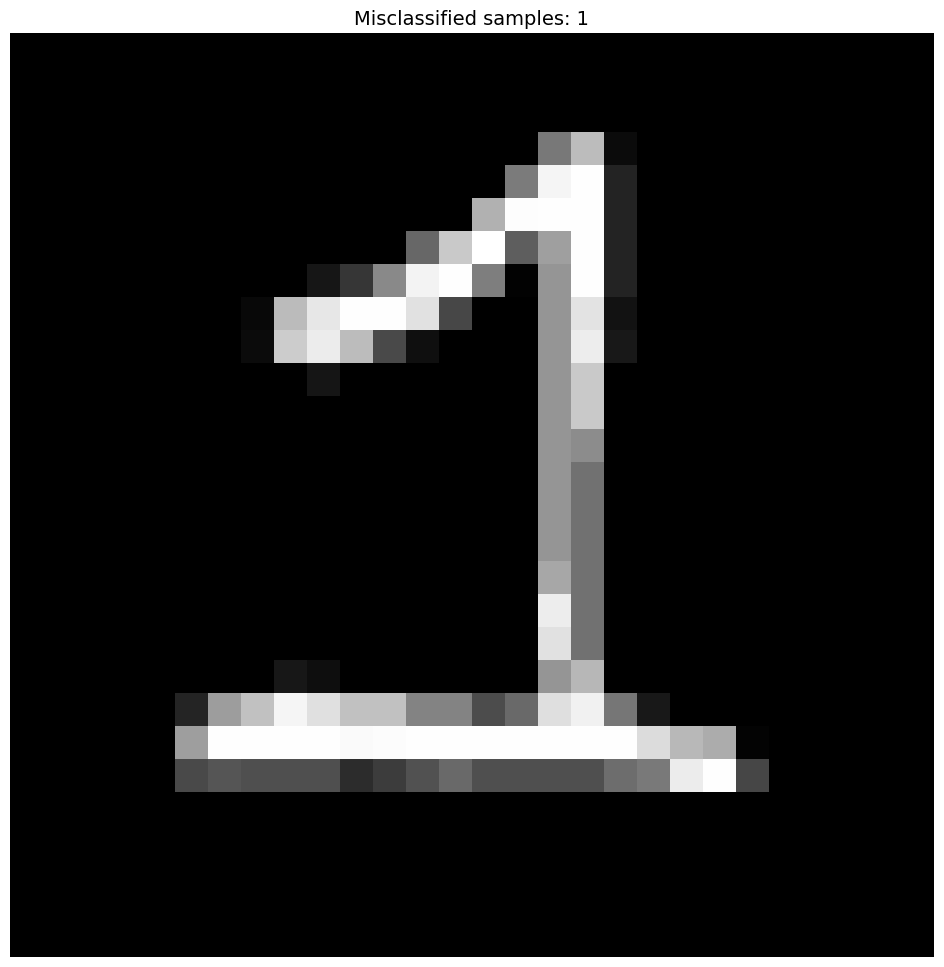

Saved 1 misclassified samples to mnist_mis.pdf


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import math

# --- find misclassified samples ---
mis = np.where((y_pred - y_test) != 0)[0]
Xmis = X_test[mis, :]  # shape: (n_mis, n_features)

# --- helper: tile images into a grid (replaces display_network) ---
def display_network(X, nrows=None, ncols=None):
    """
    X: (n_features, n_samples) — each column is one image
    Returns a tiled image array.
    """
    n = X.shape[1]
    img_size = int(math.sqrt(X.shape[0]))  # assumes square images (e.g. 28x28)

    if ncols is None:
        ncols = math.ceil(math.sqrt(n))
    if nrows is None:
        nrows = math.ceil(n / ncols)

    canvas = np.zeros((nrows * img_size, ncols * img_size))
    for idx in range(n):
        r, c = divmod(idx, ncols)
        img = X[:, idx].reshape(img_size, img_size)
        # normalize each image to [0, 1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        canvas[r*img_size:(r+1)*img_size, c*img_size:(c+1)*img_size] = img

    return canvas

# --- save misclassified digits to PDF ---
filename = 'mnist_mis.pdf'
with PdfPages(filename) as pdf:
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.axis('off')

    A = display_network(Xmis.T, ncols=Xmis.shape[0])  # match original call signature
    ax.imshow(A, interpolation='nearest', cmap='gray')

    ax.set_title(f'Misclassified samples: {len(mis)}', fontsize=14)
    pdf.savefig(fig, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f"Saved {len(mis)} misclassified samples to {filename}")
